In [13]:
import pybinding as pb
import matplotlib.pyplot as plt
import numpy as np
import copy
import os
import re
import sys
from IPython.display import Math

from scipy.spatial import cKDTree
from math import pi, sqrt
from pybinding.repository.graphene import a, a_cc, t
import pickle
import scipy.ndimage.filters

In [231]:
c0 = 0.335  # [nm] graphene interlayer spacing
# Constants and hopping values based on Kooshino's paper
V0_pi = t  # [eV] graphene NN intralayer hopping
V0_sigma = 0.48  # [eV] graphene NN interlayer hopping
rc = 0.614  # [nm] hopping fitting parameter
lc = 0.0265  # [nm] hopping fitting parameter
q_sigma = c0 * 22.18  # [nm] hopping fitting parameter
q_pi = a_cc * 22.18  # [nm] hopping fitting parameter
r0 = 0.184 * a  # [nm] hopping fitting parameter

def bilayer_graphene_AB():
    """Bilayer lattice in the AB-stacked form (Bernal-stacked)"""
    lat = pb.Lattice(a1=[a, 0], a2=[0.5*a, 0.5*np.sqrt(3)*a])

    c0 = 0.335  # [nm] interlayer spacing
    lat.add_sublattices(('A1', [0,  -a_cc/2,   0]),
                        ('B1', [0,   a_cc/2,   0]),
                        ('A2', [0,   a_cc/2, -c0]),
                        ('B2', [0, 3*a_cc/2, -c0]))
    
    d = np.sqrt(a_cc**2)
    dz = np.sqrt(0**2)
    
    v_pi = V0_pi * np.exp(q_pi * (1.0 - d / a_cc))
    v_sigma = V0_sigma * np.exp(q_sigma * (1.0 - d / c0))
    #v_pi = V0_pi * np.exp((a_cc - d) / r0)
    #v_sigma = V0_sigma * np.exp((c0  - d) / r0)

    hopping = v_pi * (1 - (dz / d) ** 2) + v_sigma * (dz / d) ** 2
    
    t = hopping
    print("t = ", t)
    
    d = np.sqrt(c0**2)
    dz = np.sqrt(c0**2)
    
    v_pi = V0_pi * np.exp(q_pi * (1.0 - d / a_cc))
    v_sigma = V0_sigma * np.exp(q_sigma * (1.0 - d / c0))
    #v_pi = V0_pi * np.exp((a_cc - d) / r0)
    #v_sigma = V0_sigma * np.exp((c0  - d) / r0)

    hopping = v_pi * (1 - (dz / d) ** 2) + v_sigma * (dz / d) ** 2
    
    t0 = hopping
    
    d = np.sqrt(a_cc**2 + c0**2)
    dz = np.sqrt(c0**2)
    
    v_pi = V0_pi * np.exp(q_pi * (1.0 - d / a_cc))
    v_sigma = V0_sigma * np.exp(q_sigma * (1.0 - d / c0))
    #v_pi = V0_pi * np.exp((a_cc - d) / r0)
    #v_sigma = V0_sigma * np.exp((c0  - d) / r0)

    hopping = v_pi * (1 - (dz / d) ** 2) + v_sigma * (dz / d) ** 2
    
    t1 = hopping
    print(t1)
    
    d = np.sqrt(a**2 + c0**2)
    dz = np.sqrt(c0**2)
    
    v_pi = V0_pi * np.exp(q_pi * (1.0 - d / a_cc))
    v_sigma = V0_sigma * np.exp(q_sigma * (1.0 - d / c0))
    #v_pi = V0_pi * np.exp((a_cc - d) / r0)
    #v_sigma = V0_sigma * np.exp((c0  - d) / r0)

    hopping = v_pi * (1 - (dz / d) ** 2) + v_sigma * (dz / d) ** 2
    
    t2 = hopping
    
    print(t2)
    lat.register_hopping_energies({'t': t, 
                                   't0': t0,
                                   't1': t1,
                                   't2': t2})
    lat.add_hoppings(
        # layer 1
        ([ 0,  0], 'A1', 'B1', 't'),
        ([ 1, -1], 'A1', 'B1', 't'),
        ([ 0, -1], 'A1', 'B1', 't'),
        # layer 2
        ([ 0,  0], 'A2', 'B2', 't'),
        ([ 1, -1], 'A2', 'B2', 't'),
        ([ 0, -1], 'A2', 'B2', 't'),
        # interlayer (on top of each other)
        ([ 0,  0], 'B1', 'A2', 't0'),
        # interlayer (first nearest ones not on top of each other)
        # Red atom to blue atoms
        ([ 0,  1], 'B2', 'A1', 't1'),
        ([ -1,  1], 'B2', 'A1', 't1'),
        ([ -1, 2], 'B2', 'A1', 't1'),
        ## Red atom to green atoms
        ([ 0,  0], 'B2', 'B1', 't1'),
        ([ -1,  1], 'B2', 'B1', 't1'),
        ([ 0, 1], 'B2', 'B1', 't1'),
        # Orange atom to blue atoms
        ([ 0,  0], 'A1', 'A2', 't1'),
        ([ 0,  -1], 'A1', 'A2', 't1'),
        ([ 1, -1], 'A1', 'A2', 't1'),
        # Orange atom to green atoms
        #([ 0,  0], 'B1', 'A2', 't1'),
        #([ 0,  1], 'B1', 'A2', 't1'),
        #([ -1, 1], 'B1', 'A2', 't1'),
        # interlayer (second nearest ones)
        # Orange atom to green atoms
        ([ -1,  0], 'B1', 'A2', 't2'),
        ([ 0,  1], 'B1', 'A2', 't2'),
        ([ -1, 1], 'B1', 'A2', 't2'),
        
        
        
    )
    lat.min_neighbors = 2
    return lat

# A1 : blue
# B1 : green
# A2 : orange
# B2 : red

model = pb.Model(bilayer_graphene_AB(), 
                 pb.translational_symmetry())

t =  -2.8
0.21144904360841013
0.049931469126983104


In [230]:
c0 = 0.335  # [nm] graphene interlayer spacing
# Constants and hopping values based on Kooshino's paper
V0_pi = t  # [eV] graphene NN intralayer hopping
V0_sigma = 0.48  # [eV] graphene NN interlayer hopping
rc = 0.614  # [nm] hopping fitting parameter
lc = 0.0265  # [nm] hopping fitting parameter
q_sigma = c0 * 22.18  # [nm] hopping fitting parameter
q_pi = a_cc * 22.18  # [nm] hopping fitting parameter
r0 = 0.184 * a  # [nm] hopping fitting parameter

def bilayer_graphene_AB():
    """Bilayer lattice in the AB-stacked form (Bernal-stacked)"""
    lat = pb.Lattice(a1=[a, 0], a2=[0.5*a, 0.5*np.sqrt(3)*a])

    c0 = 0.335  # [nm] interlayer spacing
    lat.add_sublattices(('A1', [0,  -a_cc/2,   0]),
                        ('B1', [0,   a_cc/2,   0]),
                        ('A2', [0,   a_cc/2, -c0]),
                        ('B2', [0, 3*a_cc/2, -c0]))
    
    d = np.sqrt(a_cc**2)
    dz = np.sqrt(0**2)
    
    v_pi = V0_pi * np.exp(q_pi * (1.0 - d / a_cc))
    v_sigma = V0_sigma * np.exp(q_sigma * (1.0 - d / c0))
    #v_pi = V0_pi * np.exp((a_cc - d) / r0)
    #v_sigma = V0_sigma * np.exp((c0  - d) / r0)

    hopping = v_pi * (1 - (dz / d) ** 2) + v_sigma * (dz / d) ** 2
    
    t = hopping
    print("t = ", t)
    
    d = np.sqrt(c0**2)
    dz = np.sqrt(c0**2)
    
    v_pi = V0_pi * np.exp(q_pi * (1.0 - d / a_cc))
    v_sigma = V0_sigma * np.exp(q_sigma * (1.0 - d / c0))
    #v_pi = V0_pi * np.exp((a_cc - d) / r0)
    #v_sigma = V0_sigma * np.exp((c0  - d) / r0)

    hopping = v_pi * (1 - (dz / d) ** 2) + v_sigma * (dz / d) ** 2
    
    t0 = hopping
    
    d = np.sqrt(a_cc**2 + c0**2)
    dz = np.sqrt(c0**2)
    
    v_pi = V0_pi * np.exp(q_pi * (1.0 - d / a_cc))
    v_sigma = V0_sigma * np.exp(q_sigma * (1.0 - d / c0))
    #v_pi = V0_pi * np.exp((a_cc - d) / r0)
    #v_sigma = V0_sigma * np.exp((c0  - d) / r0)

    hopping = v_pi * (1 - (dz / d) ** 2) + v_sigma * (dz / d) ** 2
    
    t1 = hopping
    print(t1)
    
    d = np.sqrt(a**2 + c0**2)
    dz = np.sqrt(c0**2)
    
    v_pi = V0_pi * np.exp(q_pi * (1.0 - d / a_cc))
    v_sigma = V0_sigma * np.exp(q_sigma * (1.0 - d / c0))
    #v_pi = V0_pi * np.exp((a_cc - d) / r0)
    #v_sigma = V0_sigma * np.exp((c0  - d) / r0)

    hopping = v_pi * (1 - (dz / d) ** 2) + v_sigma * (dz / d) ** 2
    
    t2 = 0
    
    print(t2)
    lat.register_hopping_energies({'t': t, 
                                   't0': t0,
                                   't1': t1,
                                   't2': t2})
    lat.add_hoppings(
        # layer 1
        ([ 0,  0], 'A1', 'B1', 't'),
        ([ 1, -1], 'A1', 'B1', 't'),
        ([ 0, -1], 'A1', 'B1', 't'),
        # layer 2
        ([ 0,  0], 'A2', 'B2', 't'),
        ([ 1, -1], 'A2', 'B2', 't'),
        ([ 0, -1], 'A2', 'B2', 't'),
        # interlayer (on top of each other)
        ([ 0,  0], 'B1', 'A2', 't0'),
        # interlayer (first nearest ones not on top of each other)
        # Red atom to blue atoms
        ([ 0,  1], 'B2', 'A1', 't1'),
        ([ -1,  1], 'B2', 'A1', 't1'),
        ([ -1, 2], 'B2', 'A1', 't1'),
        ## Red atom to green atoms
        ([ 0,  0], 'B2', 'B1', 't1'),
        ([ -1,  1], 'B2', 'B1', 't1'),
        ([ 0, 1], 'B2', 'B1', 't1'),
        # Orange atom to blue atoms
        ([ 0,  0], 'A1', 'A2', 't1'),
        ([ 0,  -1], 'A1', 'A2', 't1'),
        ([ 1, -1], 'A1', 'A2', 't1'),
        # Orange atom to green atoms
        #([ 0,  0], 'B1', 'A2', 't1'),
        #([ 0,  1], 'B1', 'A2', 't1'),
        #([ -1, 1], 'B1', 'A2', 't1'),
        # interlayer (second nearest ones)
        # Orange atom to green atoms
        ([ -1,  0], 'B1', 'A2', 't2'),
        ([ 0,  1], 'B1', 'A2', 't2'),
        ([ -1, 1], 'B1', 'A2', 't2'),
        
        
        
    )
    lat.min_neighbors = 2
    return lat

# A1 : blue
# B1 : green
# A2 : orange
# B2 : red

model2 = pb.Model(bilayer_graphene_AB(), 
                 pb.translational_symmetry())

t =  -2.8
0.21144904360841013
0


t =  -2.8
0.21144904360841013
0.049931469126983104


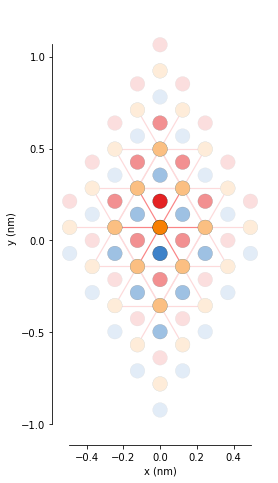

In [228]:
plt.figure(figsize=(16,8))

lat = bilayer_graphene_AB()
#lat.plot()


model.plot(num_periods=2, hopping={'draw_only': ['t2']})

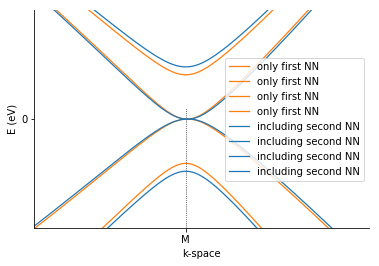

In [244]:
Gamma = [0, 0]
K1 = [-4*pi / (3*sqrt(3)*a_cc), 0]
M = [0, 2*pi / (3*a_cc)]
K2 = [2*pi / (3*sqrt(3)*a_cc), 2*pi / (3*a_cc)]

solver = pb.solver.lapack(model)
bands = solver.calc_bands(Gamma, M, K1, Gamma, step=0.01)
bands.plot(point_labels=['K', r'$\Gamma$', 'M', 'K'], color = "C1", label="only first NN")

solver = pb.solver.lapack(model2)
bands = solver.calc_bands(Gamma, M, K1, Gamma, step=0.01)
bands.plot(point_labels=['K', r'$\Gamma$', 'M', 'K'], color="C0", label="including second NN")

#plt.xlim(0, 50)
plt.xlim(3500, 4000)
plt.ylim(-1.0, 1.0)

plt.legend(loc=0)

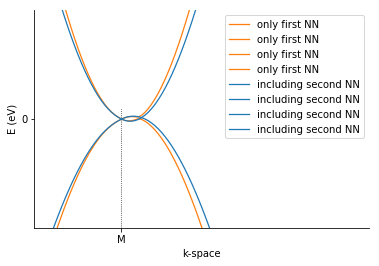

In [246]:
Gamma = [0, 0]
K1 = [-4*pi / (3*sqrt(3)*a_cc), 0]
M = [0, 2*pi / (3*a_cc)]
K2 = [2*pi / (3*sqrt(3)*a_cc), 2*pi / (3*a_cc)]

solver = pb.solver.lapack(model)
bands = solver.calc_bands(Gamma, M, K1, Gamma, step=0.01)
bands.plot(point_labels=['K', r'$\Gamma$', 'M', 'K'], color = "C1", label="only first NN")

solver = pb.solver.lapack(model2)
bands = solver.calc_bands(Gamma, M, K1, Gamma, step=0.01)
bands.plot(point_labels=['K', r'$\Gamma$', 'M', 'K'], color="C0", label="including second NN")

#plt.xlim(0, 50)
plt.xlim(3700, 3800)
plt.ylim(-0.03, 0.03)

plt.legend(loc=0)

t =  -2.8
0.21144904360841013
0.049931469126983104


(-2, 2)

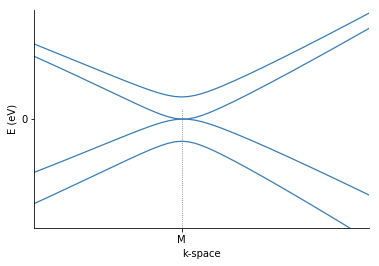

In [229]:
model = pb.Model(bilayer_graphene_AB(), 
                 pb.translational_symmetry())
solver = pb.solver.lapack(model)

Gamma = [0, 0]
K1 = [-4*pi / (3*sqrt(3)*a_cc), 0]
M = [0, 2*pi / (3*a_cc)]
K2 = [2*pi / (3*sqrt(3)*a_cc), 2*pi / (3*a_cc)]

bands = solver.calc_bands(Gamma, M, K1, Gamma)
bands.plot(point_labels=['K', r'$\Gamma$', 'M', 'K'])

#plt.xlim(0, 50)
plt.xlim(350, 400)
plt.ylim(-2, 2)